<a href="https://www.kaggle.com/code/arpit786/pytorch-cnn-gpu?scriptVersionId=287565864" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/image-classifications/example_submission.csv
/kaggle/input/image-classifications/train.csv
/kaggle/input/image-classifications/test.csv


<div style="border-radius: 12px; padding: 20px; margin: 16px 0; background: linear-gradient(135deg, #f8f9ff 0%, #f0f2ff 100%); border: 1px solid #d4d8ff; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; font-size: 15px; box-shadow: 0 4px 12px rgba(0,0,0,0.08);">

<h2 style="margin: 0 0 12px 0; color: #1a365d; font-size: 22px; font-weight: 700; text-align: center;">
<span style="background: #fff7cc; padding: 4px 12px; border-radius: 6px;">Sedan vs. Pickup Truck</span><br>
<span style="font-size: 14px; color: #4a5568;">Image Classification Challenge</span>
</h2>

<div style="background: #f7fafc; padding: 16px; border-radius: 8px; border-left: 4px solid #4299e1; margin: 12px 0; text-align: center;">
<b>CSCI6379 Intro to Deep Learning</b><br>
<b>University of Texas Rio Grande Valley (UTRGV)</b>
</div>

<div style="display: flex; gap: 20px; justify-content: center; margin: 20px 0;">
  <div style="flex: 1; background: #ebf8ff; padding: 12px; border-radius: 8px; text-align: center;">
    <b style="color: #2b6cb0; font-size: 18px;">🚗 Sedan</b>
  </div>
  <div style="flex: 1; background: #f0fff4; padding: 12px; border-radius: 8px; text-align: center;">
    <b style="color: #22543d; font-size: 18px;">🚚 Pickup Truck</b>
  </div>
</div>

<div style="background: #fffbeb; padding: 14px; border-radius: 8px; border-left: 4px solid #ed8936; margin: 12px 0;">
<strong>Task:</strong> Binary image classification using deep learning techniques
    torch.manual_seed(6379)
</div>

</div>


<div style="border-radius: 12px; padding: 20px; margin: 16px 0; background: linear-gradient(135deg, #fffaf0 0%, #fff5e6 100%); border: 1px solid #fed7aa; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; font-size: 15px;">

<h3 style="margin: 0 0 12px 0; color: #c05621; font-size: 20px; font-weight: 700;">
<span style="background: #fff7cc; padding: 4px 10px; border-radius: 6px;">📊 Dataset & Submission</span>
</h3>

<div style="display: flex; gap: 20px; margin: 16px 0;">

<div style="flex: 1; background: #fffbeb; padding: 16px; border-radius: 8px; border-left: 4px solid #f6ad55;">
**Train Data**  
<span style="background: #fef7e0; padding: 2px 6px; border-radius: 4px; font-family: monospace;">train.csv</span>  
• <b>1020 samples</b> × <span style="font-family: monospace;">65538 cols</span>  
• Col 1: <span style="color: #e53e3e;">ID</span>  
• Cols 2-65537: <span style="color: #38a169;">256×256 image pixels</span>  
• Last col: <span style="color: #4299e1;">Class (0/1)</span>
</div>

<div style="flex: 1; background: #f0fff4; padding: 16px; border-radius: 8px; border-left: 4px solid #38a169;">
**Test Data**  
<span style="background: #fef7e0; padding: 2px 6px; border-radius: 4px; font-family: monospace;">test.csv</span>  
• <b>200 samples</b> × <span style="font-family: monospace;">65537 cols</span>  
• Same format, <span style="color: #e53e3e;">NO Class label</span>
</div>

</div>

<div style="background: #f7fafc; padding: 12px; border-radius: 8px; border-left: 4px solid #3182ce; margin-top: 12px;">
**Submission**  
<span style="background: #fef7e0; padding: 2px 6px; border-radius: 4px; font-family: monospace;">example_submission.csv</span>  
• <b>200 × 2</b>: <span style="color: #e53e3e;">ID</span> + <span style="color: #38a169;">Class</span>
</div>

</div>


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Set random seeds for reproducibility
torch.manual_seed(6379)

In [5]:
df = pd.read_csv('/kaggle/input/image-classifications/train.csv')
df.head()

,ID,1,2,3,4,5,6,7,8,9,...,65528,65529,65530,65531,65532,65533,65534,65535,65536,Class
0,201,135,133,131,130,130,130,129,128,126,...,55,52,55,52,52,54,52,52,52,0
1,202,190,212,211,200,204,234,253,253,254,...,48,58,49,45,93,89,64,42,48,1
2,203,228,227,226,223,221,219,217,215,212,...,49,49,49,49,50,50,50,50,50,1
3,204,216,216,216,216,216,216,216,216,216,...,169,181,182,181,178,168,160,167,170,1
4,205,196,189,164,199,200,199,198,197,196,...,111,115,115,122,130,121,125,125,121,1


In [6]:
df.shape

(1020, 65538)


</div>

<div style="background: #f0fff4; padding: 12px; border-radius: 6px; margin-top: 12px; font-size: 13px;">
**Key points:**
• <span style="color: #38a169;">df.iloc[i, 1:65537]</span> → extracts 256×256=65,536 pixels  
• <span style="background: #e6fffa; padding: 2px 4px;">cmap='gray'</span> → proper grayscale  
• <span style="color: #4299e1;">df.iloc[i, -1]</span> → actual class label (not ID)
</div>

</div>



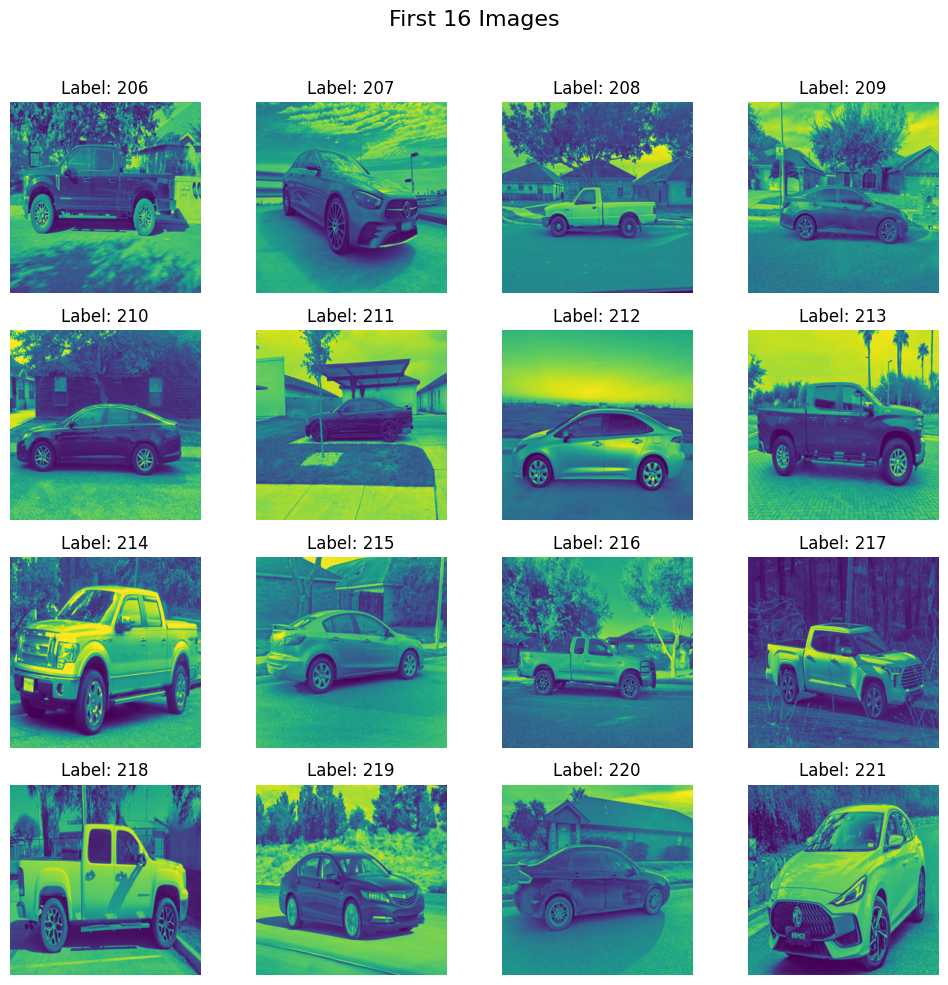

In [7]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i+5, 1:65537].values.reshape(256, 256)  # Reshape to 256x256
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i+5, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [8]:
# train test split
# Separate columns
ids = df.iloc[:, 0]              # Sample ID
X = df.iloc[:, 1:65537]          # Features
y = df.iloc[:, 65537]            # Label

In [9]:
# Split INCLUDING ids
X_train, X_test, y_train, y_test, id_train, id_val = train_test_split(
    X, y, ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
X_train.shape

(816, 65536)

In [12]:
X_test

,1,2,3,4,5,6,7,8,9,10,...,65527,65528,65529,65530,65531,65532,65533,65534,65535,65536
355,0.101961,0.090196,0.090196,0.129412,0.086275,0.188235,0.121569,0.105882,0.117647,0.105882,...,0.333333,0.360784,0.356863,0.364706,0.400000,0.388235,0.364706,0.368627,0.360784,0.403922
280,0.901961,0.839216,0.635294,0.474510,0.894118,0.627451,0.447059,0.564706,0.654902,0.627451,...,0.556863,0.501961,0.501961,0.486275,0.537255,0.560784,0.541176,0.564706,0.545098,0.549020
209,0.341176,0.027451,0.094118,0.290196,0.031373,0.184314,0.254902,0.043137,0.133333,0.270588,...,0.321569,0.321569,0.321569,0.321569,0.321569,0.321569,0.321569,0.317647,0.317647,0.317647
498,0.219608,0.356863,0.294118,0.294118,0.623529,0.505882,0.211765,0.250980,0.384314,0.349020,...,0.647059,0.666667,0.662745,0.650980,0.643137,0.654902,0.654902,0.643137,0.650980,0.643137
616,0.498039,0.498039,0.498039,0.494118,0.498039,0.498039,0.498039,0.498039,0.501961,0.505882,...,0.800000,0.752941,0.741176,0.737255,0.725490,0.721569,0.721569,0.709804,0.713725,0.760784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,0.792157,0.764706,0.741176,0.749020,0.760784,0.776471,0.796078,0.819608,0.823529,0.815686,...,0.752941,0.729412,0.800000,0.752941,0.772549,0.784314,0.745098,0.690196,0.729412,0.725490
647,0.372549,0.400000,0.384314,0.415686,0.400000,0.419608,0.407843,0.411765,0.400000,0.407843,...,0.839216,0.796078,0.815686,0.815686,0.835294,0.815686,0.819608,0.823529,0.827451,0.807843
746,0.803922,0.776471,0.603922,0.603922,0.737255,0.776471,0.796078,0.764706,0.709804,0.784314,...,0.466667,0.560784,0.619608,0.647059,0.615686,0.592157,0.466667,0.662745,0.639216,0.603922
987,0.596078,0.600000,0.607843,0.611765,0.615686,0.627451,0.647059,0.658824,0.666667,0.666667,...,0.443137,0.478431,0.443137,0.486275,0.505882,0.450980,0.349020,0.368627,0.400000,0.470588


In [13]:
X_test.shape

(204, 65536)

In [14]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,256,256)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

In [15]:
# create train_dataset object
train_dataset = CustomDataset(X_train.values, y_train.values)

In [16]:
train_dataset[0]

(tensor([[[0.5529, 0.6235, 0.6196,  ..., 0.2745, 0.2745, 0.2706],
          [0.5569, 0.6275, 0.6235,  ..., 0.2784, 0.2784, 0.2745],
          [0.5647, 0.6392, 0.6314,  ..., 0.2784, 0.2784, 0.2745],
          ...,
          [0.5647, 0.6353, 0.6353,  ..., 0.5255, 0.5216, 0.5176],
          [0.5686, 0.6431, 0.6314,  ..., 0.5176, 0.5255, 0.5176],
          [0.5647, 0.6392, 0.6353,  ..., 0.5176, 0.5255, 0.5216]]]),
 tensor(1))

In [17]:
# create test_dataset object
test_dataset = CustomDataset(X_test.values, y_test.values)

In [18]:
test_dataset

In [19]:
print(type(X_train), X_train.shape)
print(type(y_train), y_train.shape)

<class 'pandas.core.frame.DataFrame'> (816, 65536)
<class 'pandas.core.series.Series'> (816,)


In [20]:
trainloader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
testloader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

In [21]:
# Define NN Class
class MyNN(nn.Module):
    
    def __init__(self,input_features):
     
     super().__init__()
     self.features= nn.Sequential(
         nn.Conv2d(input_features,64,kernel_size=3,padding='same'),
         nn.ReLU(),
         nn.BatchNorm2d(64),
         nn.MaxPool2d(kernel_size=2,stride=2),
    
         nn.Conv2d(64,128,kernel_size=3,padding='same'),
         nn.ReLU(),
         nn.BatchNorm2d(128),
         nn.MaxPool2d(kernel_size=2,stride=2),
    
         nn.Conv2d(128,64,kernel_size=3,padding='same'),
         nn.ReLU(),
         nn.BatchNorm2d(64),
         nn.MaxPool2d(kernel_size=2,stride=2)
         
     )
     self.classifier= nn.Sequential(
         nn.Flatten(),
         nn.Linear(64*32*32,256),
         nn.ReLU(),
         nn.Dropout(p=0.4),
    
         nn.Linear(256,128),
         nn.ReLU(),
         nn.Dropout(p=0.4),
    
         nn.Linear(128,64),
         nn.ReLU(),
         nn.Dropout(p=0.4),
    
         nn.Linear(64,32),
         nn.ReLU(),
         nn.Dropout(p=0.4),
    
         nn.Linear(32,2)
     )
    def forward(self,x):
         x=self.features(x)
         x=self.classifier(x)
         return x

In [22]:
learning_rate = 0.01
epochs = 100

In [23]:
# Creating the model
model=MyNN(1)
model=model.to(device)
criterion= nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

In [24]:
# Training loop
for epoch in range(epochs):
    total_epoch_loss=0

    for batch_features,batch_labels in trainloader:
        # Move Data to GPU
        batch_features,batch_labels= batch_features.to(device),batch_labels.to(device)

        # Forward Pass
        outputs= model(batch_features)

        # Calculate loss
        loss=criterion(outputs,batch_labels)

        # Backward Pass
        optimizer.zero_grad()
        loss.backward()

        # Update Gradients
        optimizer.step()

        total_epoch_loss= total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(trainloader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')
        

Epoch: 1 , Loss: 0.6959272875235631
Epoch: 2 , Loss: 0.6873606214156518
Epoch: 3 , Loss: 0.6864686149817246
Epoch: 4 , Loss: 0.6811626828633822
Epoch: 5 , Loss: 0.6809648825572088
Epoch: 6 , Loss: 0.6519619547403775
Epoch: 7 , Loss: 0.6487829203789051
Epoch: 8 , Loss: 0.6170829993027908
Epoch: 9 , Loss: 0.5863332817187676
Epoch: 10 , Loss: 0.5208653601316305
Epoch: 11 , Loss: 0.46716359372322375
Epoch: 12 , Loss: 0.39701217871445876
Epoch: 13 , Loss: 0.3852932688135367
Epoch: 14 , Loss: 0.30698738591029096
Epoch: 15 , Loss: 0.23563211697798508
Epoch: 16 , Loss: 0.19638133937349686
Epoch: 17 , Loss: 0.09792654789411105
Epoch: 18 , Loss: 0.08769086590753151
Epoch: 19 , Loss: 0.11487963795661926
Epoch: 20 , Loss: 0.1254569969784755
Epoch: 21 , Loss: 0.08007050377245133
Epoch: 22 , Loss: 0.03191171812180143
Epoch: 23 , Loss: 0.024909989872517493
Epoch: 24 , Loss: 0.04282451148789663
Epoch: 25 , Loss: 0.034028993310550086
Epoch: 26 , Loss: 0.016714547313033387
Epoch: 27 , Loss: 0.0128487939

In [25]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, 

In [26]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in testloader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.7892156862745098


In [27]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in trainloader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

1.0
